# Building a GPT Model from Scratch

This notebook implements the **GPT-2 (124M) architecture** from the ground up in PyTorch.
It is a decoder-only Transformer, and every component is defined **exactly once**, in the
order it is used:

1. Configuration
2. Imports and tokenization
3. Layer Normalization
4. GELU activation
5. Feed-Forward network
6. Multi-head causal self-attention
7. Transformer block (assembling 3-6 with residual connections)
8. The full GPT model
9. Inspecting the model (parameter count and size)
10. Autoregressive text generation

**How to read it.** Each section states what the component does, then the design decisions
behind it: what was chosen, what the alternative was, and what changes if you pick the other
one. The code is written for readability over speed, so where a faster-but-denser
formulation exists it is named in the text rather than used.

**Scope.** This builds the architecture and runs a forward pass end to end. The weights stay
random - there is no training loop and no pretrained checkpoint loading here, so generated
text will be meaningless. That is expected, and it still verifies that every shape and mask
in the pipeline is correct.


## 1. Model Configuration

All architectural hyper-parameters live in one dictionary. These values reproduce the
smallest GPT-2 model, commonly labelled 124M.

**Design decisions**

- **A dict rather than a dataclass or individual arguments.** Every submodule receives the
  whole `cfg` object, so adding a hyper-parameter later does not mean editing constructor
  signatures down the chain. The cost is no type checking and no editor autocompletion on
  the keys - a typo like `cfg["emb_dm"]` fails at runtime, not at import.
- **`vocab_size = 50257`** is not arbitrary: 50000 learned BPE merges + 256 single-byte base
  tokens + 1 `<|endoftext|>` token. It must match the tokenizer exactly, since the output
  head produces one logit per entry.
- **`context_length = 1024`** fixes the size of the learned positional embedding table. The
  model cannot process a sequence longer than this, and unlike relative schemes (RoPE,
  ALiBi) it cannot extrapolate past it - positions beyond 1023 simply have no embedding.
- **`qkv_bias = False`.** The original OpenAI GPT-2 weights do carry biases on the Q/K/V
  projections. The flag exists so the same class can load those checkpoints; left off here
  because we train from scratch and the biases are redundant next to LayerNorm's shift.
- **`drop_rate = 0.1`** matches GPT-2's training setup. Modern reimplementations trained for
  a single pass over a very large corpus often set this to 0.0, since there is little to
  overfit to.


In [ ]:
# GPT-2 "small" (124M parameters) configuration
GPT_CONFIG_124M = {
    "vocab_size":     50257,   # number of tokens in the GPT-2 BPE vocabulary
    "context_length": 1024,    # maximum sequence length the model can attend over
    "emb_dim":        768,     # embedding / hidden dimension
    "n_heads":        12,      # number of attention heads
    "n_layers":       12,      # number of stacked Transformer blocks
    "drop_rate":      0.1,     # dropout probability
    "qkv_bias":       False,   # whether Q/K/V linear layers use a bias term
}

## 2. Imports and Tokenization

PyTorch for the model, OpenAI's `tiktoken` for GPT-2 byte-pair encoding (BPE). Two short
sentences are tokenized and stacked into one batch tensor of shape
`(batch_size, num_tokens)`, which is the input format the model expects.

**Design decisions**

- **BPE rather than word-level or character-level tokenization.** Word-level needs an
  out-of-vocabulary token for anything unseen; character-level makes sequences several times
  longer, and attention cost grows with the square of sequence length. BPE keeps common words
  as single tokens while still being able to spell out any string from byte-level pieces, so
  nothing is ever unrepresentable.
- **Using the pretrained `gpt2` encoding instead of training our own merges.** The vocabulary
  has to match `vocab_size` in the config, and reusing OpenAI's keeps this notebook
  compatible with their released weights.
- **Both sentences here happen to be 4 tokens long**, so `torch.stack` works directly. Mixed
  lengths would need padding plus an attention mask; that is skipped deliberately to keep the
  masking logic in section 6 purely causal.


In [ ]:
import torch
import torch.nn as nn
import tiktoken

# Reproducibility
torch.manual_seed(123)

# GPT-2 uses byte-pair encoding (BPE)
tokenizer = tiktoken.get_encoding("gpt2")

# Encode a couple of sentences and stack them into one batch tensor.
batch = torch.stack([
    torch.tensor(tokenizer.encode("Every effort moves you")),
    torch.tensor(tokenizer.encode("Every day holds a")),
], dim=0)

print("Batch shape:", batch.shape)   # (2 sentences, 4 tokens each)
print(batch)

Batch shape: torch.Size([2, 4])
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


## 3. Layer Normalization

`LayerNorm` normalizes activations across the **embedding dimension**, so each token vector
ends up with zero mean and unit variance. Two learnable parameters, `scale` (gamma) and
`shift` (beta), let the network scale and offset that result, which means it can partially
undo the normalization where that helps.

**Design decisions**

- **Normalizing across the embedding dimension, not the batch.** Each token is normalized
  using only its own 768 values. Nothing depends on batch size or on the other sequences in
  the batch, so the operation behaves identically during training, single-example inference,
  and token-by-token generation. BatchNorm normalizes across the batch and therefore needs
  running statistics and behaves differently in eval mode - a poor fit for variable-length
  autoregressive decoding.
- **Writing it out instead of calling `nn.LayerNorm`.** The two are numerically equivalent;
  `nn.LayerNorm` is faster because it is a fused kernel. The explicit version is here so the
  mean/variance/rescale steps are visible.
- **`unbiased=False`** divides the variance by N rather than N-1. This matches the reference
  GPT-2 implementation. With 768 elements the numerical difference is negligible, but the
  choice must match if you intend to load pretrained weights.
- **`eps = 1e-5` added inside the square root**, not after it, so the denominator can never be
  zero for a constant-valued token vector.


In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))   # learnable gain  (gamma)
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # learnable bias  (beta)

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [ ]:
# Quick sanity check: after LayerNorm each row has ~0 mean and ~1 variance.
example = torch.randn(2, 5)
ln_out = LayerNorm(emb_dim=5)(example)
print("Mean:", ln_out.mean(dim=-1).detach())
print("Var :", ln_out.var(dim=-1, unbiased=False).detach())

Mean: tensor([-2.9802e-08,  0.0000e+00])
Var : tensor([1.0000, 1.0000])


## 4. GELU Activation

GPT-2 uses the **Gaussian Error Linear Unit** rather than ReLU. GELU is smooth everywhere and
lets small negative inputs through with a small negative output, instead of clamping all of
them to exactly zero.

**Design decisions**

- **GELU over ReLU.** ReLU has zero gradient for every negative input, so a unit that gets
  pushed negative receives no gradient signal and can stop updating. GELU's gradient is
  nonzero on both sides of the origin, which removes that failure mode and empirically
  trains deep Transformer stacks better.
- **The `tanh` approximation rather than the exact `erf` form.** The exact definition uses the
  Gaussian CDF; this polynomial-plus-`tanh` version is what the original GPT-2 shipped with,
  and reproducing it keeps activations bit-comparable with the reference implementation. In
  PyTorch the same thing is available as `nn.GELU(approximate="tanh")`.
- **Implemented as an `nn.Module` with no parameters.** It could be a plain function; the
  module form lets it drop straight into the `nn.Sequential` in the next section.


In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # tanh-based approximation of GELU (as used in the original GPT-2)
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

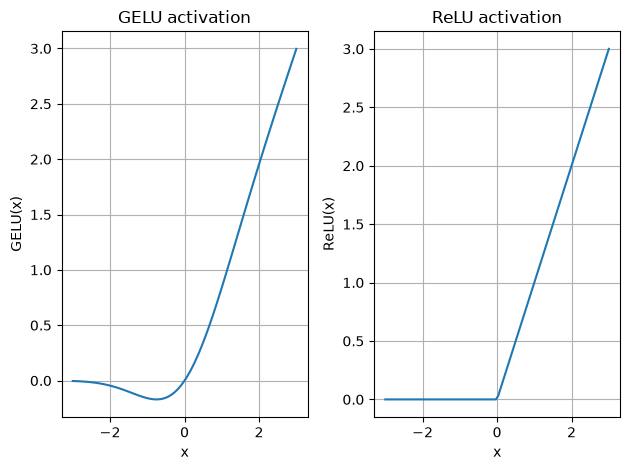

In [ ]:
# Visualize GELU vs. ReLU to see the smooth, non-zero-for-negatives behaviour.
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, 100)
for i, (fn, label) in enumerate([(GELU(), "GELU"), (nn.ReLU(), "ReLU")], start=1):
    plt.subplot(1, 2, i)
    plt.plot(x, fn(x))
    plt.title(f"{label} activation")
    plt.xlabel("x"); plt.ylabel(f"{label}(x)"); plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Feed-Forward Network

Each Transformer block contains a position-wise feed-forward network. It expands the
embedding dimension by 4x, applies GELU, then contracts back to the original width.

**Design decisions**

- **Position-wise: the same weights applied to every token independently.** No information
  moves between positions here. All cross-token mixing happens in attention, so the two
  sub-layers have cleanly separated jobs - attention decides *what to look at*, the FFN
  decides *what to compute* with what it found.
- **The 4x expansion factor.** This is GPT-2's convention and it is where most of the model's
  parameters live: 2 x 768 x 3072 per block, versus 4 x 768 x 768 for attention. Widening
  before the nonlinearity gives GELU a higher-dimensional space to carve up; contracting
  afterwards keeps the residual stream at a fixed 768 so blocks remain stackable.
- **Two linear layers rather than more.** Depth in this architecture comes from stacking
  blocks, not from deepening the FFN.
- **Biases left on** (`nn.Linear` defaults to `bias=True`), matching GPT-2.


In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),   # expand  (768 -> 3072)
            GELU(),                                          # activation
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),   # contract (3072 -> 768)
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
# The FFN preserves shape: (batch, tokens, emb_dim) in -> same shape out.
ff_out = FeedForward(GPT_CONFIG_124M)(torch.rand(2, 3, 768))
print("FeedForward output shape:", ff_out.shape)

FeedForward output shape: torch.Size([2, 3, 768])


## 6. Multi-Head Causal Self-Attention

This is where tokens exchange information. Each token emits a **query** describing what it is
looking for, a **key** describing what it offers, and a **value** carrying the content it
contributes. Every query is scored against every key, the scores are turned into weights with
a softmax, and each token's output is the weighted sum of values.

**Design decisions**

- **Multiple heads instead of one wide attention.** `d_out` is split into `num_heads`
  independent slices of `head_dim = d_out / num_heads`, each with its own attention pattern,
  and the results are concatenated. One head can only produce a single weighted average per
  token; twelve can attend to twelve different things at once. Splitting rather than adding
  heads keeps the parameter count identical to single-head attention.
- **Three separate `Linear` layers for Q, K, V.** A single fused `Linear(d_in, 3 * d_out)`
  followed by a split is one matmul instead of three and is what performance-focused
  implementations use. Three layers are kept here because the naming makes the roles obvious.
- **A causal mask, applied by setting future scores to `-inf` before the softmax.** After the
  softmax those entries become exactly 0, so position *i* can attend only to positions
  <= *i*. Without this, predicting token *i+1* would have access to token *i+1* itself and
  the training objective would be trivially satisfiable.
- **The mask is a registered buffer, not a parameter or a local variable.** As a buffer it
  moves with `.to(device)` and is saved in `state_dict`, but receives no gradient. It is
  allocated once at full `context_length` and sliced to `[:num_tokens, :num_tokens]` per
  call, which avoids rebuilding a triangular matrix on every forward pass.
- **Scores divided by `sqrt(head_dim)` before the softmax.** The dot product of two
  `head_dim`-length vectors has variance proportional to `head_dim`, so without scaling the
  scores grow with head width, the softmax saturates toward one-hot, and its gradient
  vanishes. Dividing keeps the score variance near 1 regardless of head size.
- **Dropout applied to the attention weights, after the softmax.** This means the surviving
  weights no longer sum to 1 during training. That is intentional and is what GPT-2 does; it
  forces each token to not depend on any single source position.
- **A final `out_proj` after merging heads.** Concatenation alone leaves each head's output
  confined to its own slice of the 768 dimensions. The output projection is what lets heads
  combine.

![image.png](image.png)


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads   # dimension handled by each head

        # Separate learnable projections for queries, keys, and values.
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)   # combines the heads back together
        self.dropout = nn.Dropout(dropout)

        # Causal mask (upper triangular, excluding the diagonal). Registered as a
        # buffer so it moves with the model to GPU/CPU but is not a trained parameter.
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # 1) Project inputs to Q, K, V  ->  (b, num_tokens, d_out)
        keys    = self.W_key(x)
        queries = self.W_query(x)
        values  = self.W_value(x)

        # 2) Split into heads: (b, num_tokens, num_heads, head_dim)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # 3) Move the head dimension forward: (b, num_heads, num_tokens, head_dim)
        keys    = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values  = values.transpose(1, 2)

        # 4) Scaled dot-product attention scores for every head.
        attn_scores = queries @ keys.transpose(2, 3)

        # 5) Apply the causal mask (block attention to future tokens).
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # 6) Scale by sqrt(head_dim), softmax over the last dim, then dropout.
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 7) Weighted sum of values, then merge heads back to (b, num_tokens, d_out).
        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        # 8) Final output projection.
        return self.out_proj(context_vec)

## 7. The Transformer Block

A block wires the attention and feed-forward sub-layers together using **pre-LayerNorm**
placement and **residual connections**:

```
x -> LayerNorm -> Attention   -> Dropout -> (+ x)  ->  h
h -> LayerNorm -> FeedForward -> Dropout -> (+ h)  ->  out
```

**Design decisions**

- **Pre-LN rather than post-LN.** The 2017 Transformer normalized *after* the residual
  addition. Pre-LN normalizes the input to each sub-layer instead, leaving an unbroken
  identity path from the first block's input to the last block's output. Gradients travel
  that path without passing through any normalization, which is what makes a 12-block (or
  96-block) stack trainable without a carefully tuned learning-rate warmup. The cost is that
  the final block's output is never normalized, which is why section 8 adds `final_norm`.
- **Residual connections at all.** Each sub-layer computes a *change* to be added to the
  running representation rather than replacing it. A block that has learned nothing useful
  contributes approximately zero, so adding depth cannot make the model worse by
  construction.
- **Dropout on the sub-layer output, before the addition.** The residual path itself is never
  dropped, so the identity route always stays intact.
- **One `drop_shortcut` module reused for both sub-layers.** Dropout holds no state between
  calls - it samples a fresh mask each time - so sharing the module is safe and equivalent to
  having two.
- **The residual stream keeps a constant width of `emb_dim` throughout.** That is what allows
  `n_layers` identical blocks to be stacked with no shape adapters between them.

![transformer.png](transformer.png)


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # --- Attention sub-layer (with residual connection) ---
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        # --- Feed-forward sub-layer (with residual connection) ---
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [ ]:
# A single block preserves the input shape (batch, tokens, emb_dim).
block_out = TransformerBlock(GPT_CONFIG_124M)(torch.rand(2, 4, 768))
print("TransformerBlock output shape:", block_out.shape)

TransformerBlock output shape: torch.Size([2, 4, 768])


## 8. The Full GPT Model

Assembling the complete model:

1. **Token embeddings** map token IDs to vectors.
2. **Positional embeddings** add information about each token's position.
3. A stack of `n_layers` **Transformer blocks** processes the sequence.
4. A **final LayerNorm** normalizes the output of the last block.
5. A linear **output head** projects each position to vocabulary-sized logits.

**Design decisions**

- **Positional embeddings are learned, not sinusoidal.** GPT-2 trains a
  `(context_length, emb_dim)` lookup table from scratch. Sinusoidal encodings are
  parameter-free and extrapolate to unseen lengths; learned ones fit the data better within
  the trained range but stop dead at `context_length`. Modern models mostly use neither and
  apply rotary embeddings inside attention instead.
- **Position is added to the token embedding, not concatenated.** Concatenation would need
  extra dimensions and widen every downstream layer. Addition keeps the residual stream at
  768 and lets the model allocate whatever subspace it wants to positional information.
- **Both embeddings are looked up, then dropout is applied once to their sum**, rather than to
  each separately.
- **`final_norm` before the output head.** This is required by the pre-LN choice in section 7:
  the last block's residual output has not passed through a normalization, and feeding an
  unnormalized, potentially large-magnitude vector straight into the vocabulary projection
  destabilizes training.
- **The blocks are held in `nn.Sequential`.** That works only because a block takes one tensor
  and returns one tensor. The moment a block needs a second argument - an attention mask, or a
  KV cache during generation - this has to become an `nn.ModuleList` with an explicit loop.
- **`out_head` has `bias=False`.** A per-vocabulary-entry bias would act as a learned prior on
  token frequency; GPT-2 omits it, and the softmax is shift-invariant so a single global bias
  would do nothing anyway.

![full-pipeline.png](full-pipeline.png)


In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of Transformer blocks.
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        # Output projection to vocabulary logits (no bias, as in GPT-2).
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)
        # Position ids [0, 1, ..., seq_len-1] on the same device as the input.
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds     # combine token + positional information
        x = self.drop_emb(x)
        x = self.trf_blocks(x)          # the bulk of the computation
        x = self.final_norm(x)
        logits = self.out_head(x)       # (batch, seq_len, vocab_size)
        return logits

In [ ]:
# Instantiate the model and run our tokenized batch through it.
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Input batch shape :", batch.shape)
print("Output logits shape:", logits.shape)   # (2, 4, 50257)

Input batch shape : torch.Size([2, 4])
Output logits shape: torch.Size([2, 4, 50257])


## 9. Inspecting the Model

Confirming the parameter count and estimating the memory footprint.

The raw count comes out around 163M, not the advertised 124M. The difference is **weight
tying**: GPT-2 reuses the token embedding matrix as the output projection, since both are
`(vocab_size, emb_dim)` mappings between token IDs and vectors, just in opposite directions.
That single 50257 x 768 matrix is about 38.6M parameters, and counting it once instead of
twice gives the 124M figure.

**Design decisions**

- **This implementation does not actually tie the weights** - `tok_emb` and `out_head` are
  separate modules with separate parameters. The subtraction below reports what the count
  *would* be under tying; it does not change the model. Keeping them untied costs memory but
  makes each layer's role easier to read. To tie them for real you would add
  `self.out_head.weight = self.tok_emb.weight` after both are constructed, and the two would
  then share one gradient.
- **The size estimate assumes float32, 4 bytes per parameter.** That covers the weights only.
  Training also needs gradients (another 4 bytes each), Adam's two optimizer states (8 more),
  and activations for the backward pass - in practice several times the number below.


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# What the count would be under weight tying. This model does NOT tie them --
# tok_emb and out_head are separate parameters; this only reports the figure.
params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Parameters with weight tying: {params_gpt2:,}")

# Rough memory footprint assuming float32 (4 bytes per parameter).
size_mb = total_params * 4 / (1024 * 1024)
print(f"Approx. model size: {size_mb:.2f} MB")

Total parameters: 163,009,536
Parameters with weight tying: 124,412,160
Approx. model size: 621.83 MB


## 10. Generating Text

Generation is **autoregressive**: feed the current sequence to the model, take the logits at
the last position, pick the next token, append it, and repeat with the extended sequence.

**Design decisions**

- **Greedy decoding via `argmax`.** Always taking the highest-scoring token is deterministic
  and makes the output easy to reason about, but it is also why real models sound repetitive
  under it - there is no mechanism to escape a loop once entered. Temperature scaling, top-k,
  and nucleus sampling all slot in at exactly the `probas` line below.
- **The `softmax` before `argmax` is mathematically redundant.** Softmax is monotonic, so
  `argmax(softmax(logits)) == argmax(logits)`. It is kept because it marks the point where the
  distribution exists, which is where any sampling strategy would be inserted.
- **Only the final position's logits are used.** The model emits a prediction for every
  position in the sequence; during generation all but the last are discarded. During training
  every one of them is a supervised target, which is what makes the objective efficient.
- **The context is truncated to the last `context_size` tokens** each step. Once generation
  runs past the window, the earliest tokens fall out - the model has no memory beyond it.
- **No KV cache.** Each step re-runs the full forward pass over the entire sequence, so keys
  and values for tokens already processed are recomputed every time. Caching them is the
  standard optimization and turns per-step cost from quadratic to linear in sequence length;
  it is left out here because it would require threading mutable state through every module.
- **`torch.no_grad()` and `model.eval()`.** The first skips building the autograd graph, which
  is unnecessary during inference and saves memory. The second disables dropout, without which
  generation would be nondeterministic even under greedy decoding.

The model is **untrained**, so the output is meaningless. What it does confirm is that
tokenization, embedding, twelve blocks of attention, masking, and decoding all run end to end
with correct shapes.


In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    """Greedy autoregressive generation.

    idx: (batch, n_tokens) tensor of token IDs for the current context.
    """
    for _ in range(max_new_tokens):
        # Keep only the last `context_size` tokens (the model's window).
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        # Look only at the prediction for the final position.
        logits = logits[:, -1, :]                       # (batch, vocab_size)
        # Softmax is monotonic so it does not change the argmax; it marks where a
        # sampling strategy (temperature / top-k) would replace the greedy pick.
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # greedy pick

        # Append the predicted token and continue.
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [ ]:
start_context = "Hello, I am"
encoded = torch.tensor(tokenizer.encode(start_context)).unsqueeze(0)  # add batch dim
print("Encoded input:", encoded.tolist())

model.eval()  # disable dropout for deterministic generation
out = generate_text_simple(
    model=model,
    idx=encoded,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"],
)

print("Generated token IDs:", out.tolist())
print("Decoded text:", tokenizer.decode(out.squeeze(0).tolist()))

Encoded input: [[15496, 11, 314, 716]]


Generated token IDs: [[15496, 11, 314, 716, 27018, 24086, 47843, 30961, 42348, 7267]]
Decoded text: Hello, I am Featureiman Byeswickattribute argue


## Summary

A complete GPT-2 (124M) architecture, built up in the order it executes:

- **LayerNorm**, **GELU**, and **FeedForward** - each defined once, each explicit rather than
  delegated to a PyTorch builtin, so the arithmetic is visible.
- **Multi-head causal self-attention** with the causal mask held as a registered buffer and
  scores scaled by `sqrt(head_dim)`.
- A **pre-LayerNorm Transformer block** whose residual path runs unbroken from input to
  output.
- The assembled **GPTModel**: learned token and positional embeddings added together, twelve
  blocks, a final norm required by the pre-LN placement, and a bias-free output head.
- **Greedy generation**, demonstrating the forward pass end to end on random weights.

The choices that would most change this model if reversed: pre-LN vs post-LN (trainability at
depth), learned vs rotary positional embeddings (whether context length can be extended), and
tied vs untied embeddings (about 38M parameters).

The next step is a **training loop** - a cross-entropy objective over next-token targets, an
optimizer, and a real corpus - after which the generated text becomes coherent.
